# Implementing a Multi-Layer Neural Network from Scratch

In this tutorial, we'll build a neural network with an arbitrary number of hidden layers using only NumPy. By the end, you'll understand how forward and backward propagation actually work, with no PyTorch or TensorFlow, just matrix math.

**Prerequisites:** Basic Python and NumPy. Some linear algebra and calculus is helpful, but I'll provide all the formulas. If you want to see where backprop comes from, I derived it from scratch in my notes: [Page 12-13](https://raw.githubusercontent.com/truthixify/learning-journal/main/assets/Advanced_Learning_Algorithms_1779506437587_0.pdf).

**What we'll cover:**

1. What neural networks are and why we use activation functions
2. Defining multiple activation functions
3. Setting up layer dimensions
4. Initializing weights with proper scaling
5. Forward propagation: computing predictions
6. Backward propagation: computing gradients via the chain rule
7. Updating parameters with gradient descent
8. Putting it all together in a training loop
9. Making predictions and visualizing decision boundaries
10. Testing on multiple non-linear problems

## What is a neural network?

A neural network is a function that maps inputs to outputs by stacking layers of weighted sums and non-linear activations.

Each layer takes the previous layer's output, multiplies it by a weight matrix, adds a bias, and applies a non-linear function. The output of one layer becomes the input to the next.

The key insight: with enough hidden layers and units, a neural network can approximate almost any function. This makes them much more expressive than logistic regression alone, which can only learn linear decision boundaries.

We'll build a network that supports binary classification using cross-entropy loss.

## Why do we need activation functions?

A natural question that comes up when learning about neural network is why do we need activation functions?

Without an activation function, transformation from one layer to the becomes a linear transformation. For example, with two layers:

$$Z_2 = W_2 (W_1 X + b_1) + b_2 = (W_2 W_1) X + (W_2 b_1 + b_2)$$

This is just another linear function, which can be represented by a single layer and this turns to linear/logistic regression. The depth gives us nothing.

Adding a non-linear activation breaks this collapse and lets the network learn complex, curved decision boundaries.

## Setting up

We only need NumPy for the math and matplotlib for visualization.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# Set seed for reproducibility
np.random.seed(42)

## Activation functions

We'll define a few common activations so we can pick which one to use:

**Sigmoid** squashes values into (0, 1). Common at the output layer for binary classification. Used to be common in hidden layers, but causes vanishing gradients in deep networks.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Tanh** is like sigmoid but maps to (-1, 1) and is centered at zero. Often works better than sigmoid in hidden layers.

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

**ReLU** outputs $\max(0, z)$. The default choice for hidden layers in modern networks. Fast to compute and doesn't suffer from vanishing gradients on the positive side.

$$\text{ReLU}(z) = \max(0, z)$$

For backpropagation, we also need the derivative of each activation. The derivatives have clean closed forms:

- $\sigma'(z) = \sigma(z)(1 - \sigma(z)) = A(1 - A)$
- $\tanh'(z) = 1 - \tanh^2(z) = 1 - A^2$
- $\text{ReLU}'(z) = 1$ if $z > 0$, else $0$

In [37]:
def sigmoid(z):
    """
    Sigmoid activation: maps any real number to (0, 1).

    Formula: sigma(z) = 1 / (1 + exp(-z))
    """
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(A):
    """
    Derivative of sigmoid, expressed in terms of the activation A.

    Since sigma'(z) = sigma(z) * (1 - sigma(z)), and A = sigma(z),
    we can compute the derivative directly from A without needing z.
    """
    return A * (1 - A)


def tanh(z):
    """
    Tanh activation: maps any real number to (-1, 1).
    """
    return np.tanh(z)


def tanh_derivative(A):
    """
    Derivative of tanh, expressed in terms of A.

    tanh'(z) = 1 - tanh(z)^2, and A = tanh(z), so derivative = 1 - A^2.
    """
    return 1 - A**2


def relu(z):
    """
    ReLU activation: outputs max(0, z) element-wise.
    """
    return np.maximum(0, z)


def relu_derivative(Z):
    """
    Derivative of ReLU.

    ReLU'(z) = 1 if z > 0, else 0. This depends on Z (pre-activation),
    not A (post-activation), which is why we pass Z here rather than A.
    """
    return (Z > 0).astype(float)

## Activation dispatcher

To make it easy to switch between activations, we register each one in a dictionary keyed by name. Each entry stores both the function and its derivative as a pair.

This way, our forward and backward propagation functions can accept a string like `'relu'` and look up the right function at runtime.

In [38]:
# Map activation names to their function and derivative.
# This lets us specify activations by name throughout the rest of the code.
ACTIVATIONS = {
    'sigmoid': (sigmoid, sigmoid_derivative),
    'tanh':    (tanh, tanh_derivative),
    'relu':    (relu, relu_derivative)
}

## Visualizing the activations

Let's see how each activation behaves across a range of inputs. The shape of each function determines how the network learns.

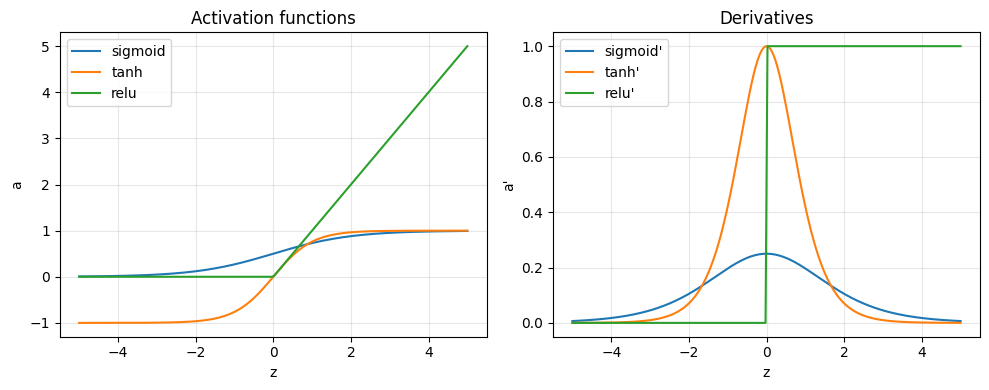

In [39]:
z = np.linspace(-5, 5, 200)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(z, sigmoid(z), label='sigmoid')
plt.plot(z, tanh(z), label='tanh')
plt.plot(z, relu(z), label='relu')
plt.title('Activation functions')
plt.xlabel('z')
plt.ylabel('a')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(z, sigmoid_derivative(sigmoid(z)), label="sigmoid'")
plt.plot(z, tanh_derivative(tanh(z)), label="tanh'")
plt.plot(z, relu_derivative(z), label="relu'")
plt.title('Derivatives')
plt.xlabel('z')
plt.ylabel("a'")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Defining the network architecture

The architecture is described by a list of layer sizes. For example, `[2, 4, 3, 1]` means:

- Input layer: 2 features per example
- Hidden layer 1: 4 neurons
- Hidden layer 2: 3 neurons
- Output layer: 1 neuron (binary classification)

The first entry is determined by your data (number of features), and the last is determined by your task (number of outputs). The middle entries are choices you make. More hidden units gives the network more capacity to learn complex patterns.

This function builds that list from the input data and a list of hidden layer sizes.

In [40]:
def layer_sizes(X, Y, n_hs):
    """
    Build the full list of layer sizes for the network.

    Args:
        X (np.ndarray): Input data, shape (n_features, m)
        Y (np.ndarray): Labels, shape (n_outputs, m)
        n_hs (list): Sizes of the hidden layers, e.g. [4, 3]

    Returns:
        list: All layer sizes from input to output, e.g. [2, 4, 3, 1]
    """
    n_x = X.shape[0]  # Number of input features
    n_y = Y.shape[0]  # Number of output units

    return [n_x] + list(n_hs) + [n_y]

## Initializing the weights

The weights are the parameters the network learns. Each layer has:

- A weight matrix $W^{[l]}$ of shape $(n^{[l]}, n^{[l-1]})$
- A bias vector $b^{[l]}$ of shape $(n^{[l]}, 1)$

How we initialize these matters a lot. If we set them all to zero, all neurons would compute the same thing and update identically. The network would never learn. If we set them to large random values, the activations and gradients can explode.

The right initialization scheme depends on the activation function:

**Xavier initialization** for sigmoid and tanh:

$$W^{[l]} \sim \mathbf{N}\left(0, \frac{1}{n^{[l-1]}}\right)$$

**He initialization** for ReLU:

$$W^{[l]} \sim \mathbf{N}\left(0, \frac{2}{n^{[l-1]}}\right)$$

The factor of 2 in He init compensates for the fact that ReLU zeros out half the activations on average, so weights need to be slightly larger to maintain variance across layers.

Biases are always initialized to zero.

In [41]:
def init_params(ls, activation='relu'):
    """
    Initialize weights and biases for every layer.

    Uses He initialization (factor 2) for ReLU activations and
    Xavier initialization (factor 1) for sigmoid and tanh.

    Args:
        ls (list): All layer sizes, including input and output
        activation (str): The hidden activation, controls the init scheme

    Returns:
        dict: Parameters with keys 'W1', 'b1', 'W2', 'b2', etc.
    """
    parameters = {}

    # He init for ReLU, Xavier for everything else
    factor = 2.0 if activation == 'relu' else 1.0

    # Loop over each layer (skipping the input, which has no weights)
    for i in range(1, len(ls)):
        # W has shape (current_layer_size, previous_layer_size)
        W = np.random.randn(ls[i], ls[i-1]) * np.sqrt(factor / ls[i-1])

        # b has shape (current_layer_size, 1), one bias per neuron
        b = np.zeros((ls[i], 1))

        parameters[f"W{i}"] = W
        parameters[f"b{i}"] = b

    return parameters

## Forward propagation

Forward propagation computes the network's output for a given input. We pass the input through each layer in sequence, computing:

$$Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}$$
$$A^{[l]} = g^{[l]}(Z^{[l]})$$

Where $A^{[0]} = X$ (the input is the activation of layer 0) and $g^{[l]}$ is the activation function for layer $l$.

We save all the intermediate $Z$ and $A$ values in a `cache` so backpropagation can use them later. This avoids recomputing them during the backward pass.

The final activation $A^{[L]}$ is the network's prediction.

We allow different activations for hidden layers and the output layer. For binary classification, sigmoid at the output is what we use regardless of what we use in hidden layers.

In [42]:
def forward_propagation(parameters, ls, X, hidden_activation='relu', output_activation='sigmoid'):
    """
    Compute the network's predictions through forward propagation.

    Starting from the input, each layer's output becomes the next layer's input.
    All intermediate values are cached so backpropagation can reuse them.

    Different activations can be used for hidden layers vs the output layer.

    Args:
        parameters (dict): Weights and biases from init_params
        ls (list): All layer sizes
        X (np.ndarray): Input data, shape (n_features, m)
        hidden_activation (str): Activation for hidden layers
        output_activation (str): Activation for the output layer

    Returns:
        tuple: (final_activations, cache)
            final_activations: predictions of the network, shape (n_outputs, m)
            cache: dict of intermediate Z and A values for each layer
    """
    cache = {"A0": X}  # The input is the "activation" of layer 0
    L = len(ls) - 1    # Index of the output layer

    # Look up the activation functions by name
    hidden_act, _ = ACTIVATIONS[hidden_activation]
    output_act, _ = ACTIVATIONS[output_activation]

    # Walk forward through every layer
    for i in range(1, len(ls)):
        W = parameters[f"W{i}"]
        b = parameters[f"b{i}"]
        A_prev = cache[f"A{i-1}"]

        # Linear step: weighted sum plus bias
        Z = W @ A_prev + b

        # Non-linear step: apply the appropriate activation
        if i == L:
            A = output_act(Z)
        else:
            A = hidden_act(Z)

        # Save both for backprop
        cache[f"Z{i}"] = Z
        cache[f"A{i}"] = A

    # The output is the activation of the last layer
    return cache[f"A{L}"], cache

## Backward propagation

Backward propagation computes how each weight should change to reduce the loss. It applies the chain rule from calculus, working backward from the output layer to the input.

At each layer, we compute three things:

$$
\begin{aligned}
dZ^{[l]} &= (W^{[l+1]T} \cdot dZ^{[l+1]}) \odot g'^{[l]}(Z^{[l]}) \\
dW^{[l]} &= \frac{1}{m} dZ^{[l]} \cdot (A^{[l-1]})^T \\
db^{[l]} &= \frac{1}{m} \sum dZ^{[l]}
\end{aligned}
$$

Where $\odot$ is element-wise multiplication.

For the **output layer**, the formula for $dZ$ simplifies dramatically because of how sigmoid and binary cross-entropy interact:

$$dZ^{[L]} = A^{[L]} - Y$$

Notice the recursive structure: $dZ$ for layer $l$ depends on $dZ$ for layer $l+1$. This is why we must walk backward. We can't compute earlier gradients without the later ones.

In [43]:
def backward_propagation(parameters, cache, ls, X, Y, hidden_activation='relu'):
    """
    Compute gradients for every parameter using the chain rule.

    Walks backward from the output to the input, computing the gradient of
    the loss with respect to each layer's pre-activation (dZ), weights (dW),
    and biases (db).

    The output layer assumes binary cross-entropy plus sigmoid pairing, which
    gives dZ = A - Y directly.

    Args:
        parameters (dict): Weights and biases
        cache (dict): Cached Z and A values from forward propagation
        ls (list): All layer sizes
        X (np.ndarray): Input data
        Y (np.ndarray): True labels
        hidden_activation (str): Activation used in hidden layers

    Returns:
        dict: Gradients for each layer's weights and biases
    """
    grads = {}
    m = X.shape[1]     # Number of training examples
    L = len(ls) - 1    # Output layer index

    # Get the derivative function for hidden layers
    _, hidden_act_derivative = ACTIVATIONS[hidden_activation]

    # Walk backward through layers
    for i in reversed(range(1, len(ls))):
        A = cache[f"A{i}"]
        Z = cache[f"Z{i}"]
        A_prev = cache[f"A{i-1}"]

        if i == L:
            # Output layer: simplified formula from sigmoid plus cross-entropy
            dZ = A - Y
        else:
            # Hidden layer: propagate error from the next layer back
            dZ_next = grads[f"dZ{i+1}"]
            W_next = parameters[f"W{i+1}"]

            # ReLU's derivative needs Z; sigmoid and tanh need A
            if hidden_activation == 'relu':
                dZ = (W_next.T @ dZ_next) * hidden_act_derivative(Z)
            else:
                dZ = (W_next.T @ dZ_next) * hidden_act_derivative(A)

        # Gradients for this layer's parameters
        dW = (1/m) * dZ @ A_prev.T
        db = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        grads[f"dW{i}"] = dW
        grads[f"db{i}"] = db
        grads[f"dZ{i}"] = dZ  # Cached for the previous layer's computation

    return grads

## Updating the parameters

Once we have the gradients, we apply gradient descent. For each parameter:

$$
\begin{aligned}
W^{[l]} &:= W^{[l]} - \alpha \cdot dW^{[l]} \\
b^{[l]} &:= b^{[l]} - \alpha \cdot db^{[l]}
\end{aligned}
$$

Where $\alpha$ is the learning rate. The gradient tells us the direction that increases the loss, so we move in the opposite direction to decrease it.

The learning rate controls step size:

- Too small: training is slow
- Too large: training overshoots and may not converge
- Just right: training converges steadily

For sigmoid networks with Xavier initialization, learning rates around 0.1 to 1.0 typically work well. For ReLU networks with He initialization, slightly smaller rates around 0.01 to 0.1 are often better.

In [44]:
def update_params(parameters, grads, ls, learning_rate):
    """
    Update all parameters using gradient descent.

    For each layer, subtract learning_rate times the gradient from each
    parameter. This moves the parameter in the direction that reduces loss.

    Args:
        parameters (dict): Current weights and biases
        grads (dict): Gradients from backward_propagation
        ls (list): All layer sizes
        learning_rate (float): Step size for gradient descent

    Returns:
        dict: Updated parameters
    """
    for i in range(1, len(ls)):
        parameters[f"W{i}"] -= learning_rate * grads[f"dW{i}"]
        parameters[f"b{i}"] -= learning_rate * grads[f"db{i}"]

    return parameters

## Putting it all together

The training loop repeats the three steps (forward prop, backward prop, parameter update) many times until the network converges.

Each iteration:

1. **Forward prop:** compute predictions on the training data
2. **Backward prop:** compute gradients
3. **Update:** adjust parameters using the gradients

We also track the cost (loss averaged over all examples) so we can see if the network is actually learning. The cost should decrease over time.

We're using full-batch gradient descent here, where every iteration uses all training examples. For larger datasets you'd switch to mini-batch, but for small problems this is simpler and works fine.

In [45]:
def multi_layer_neural_network(X, Y, n_hs, num_epochs=10000, learning_rate=0.01,
       hidden_activation='relu', output_activation='sigmoid', print_cost=False):
    """
    Train a neural network on data X with labels Y.

    Args:
        X (np.ndarray): Input data, shape (n_features, m)
        Y (np.ndarray): Labels, shape (n_outputs, m)
        n_hs (list): Sizes of hidden layers, e.g. [4, 3]
        num_epochs (int): Number of training iterations
        learning_rate (float): Step size for gradient descent
        hidden_activation (str): Activation for hidden layers
        output_activation (str): Activation for the output layer
        print_cost (bool): If True, print cost every 200 epochs

    Returns:
        tuple: (parameters, layer_sizes) for the trained model
    """
    # Set up the architecture and initial parameters
    ls = layer_sizes(X, Y, n_hs)
    parameters = init_params(ls, activation=hidden_activation)

    # Training loop
    for epoch in range(num_epochs):
        # Forward: compute predictions
        A_out, cache = forward_propagation(parameters, ls, X, hidden_activation, output_activation)

        # Backward: compute gradients
        grads = backward_propagation(parameters, cache, ls, X, Y, hidden_activation)

        # Update: take a gradient step
        parameters = update_params(parameters, grads, ls, learning_rate)

        # Optionally track progress
        if print_cost and epoch % 200 == 0:
            # Binary cross-entropy loss
            cost = -np.mean(Y * np.log(A_out + 1e-15) + (1 - Y) * np.log(1 - A_out + 1e-15))
            print(f"Epoch {epoch}: cost = {cost:.4f}")

    return parameters, ls

## Making predictions

To predict, we run forward propagation on new data and threshold the output. For binary classification with sigmoid output:

- If the network outputs > 0.5, predict class 1
- Otherwise, predict class 0

Different thresholds shift the precision/recall trade-off, but 0.5 is the standard default.

In [46]:
def predict(parameters, ls, X, hidden_activation='relu', output_activation='sigmoid'):
    """
    Predict classes for new examples.

    Args:
        parameters (dict): Trained weights and biases
        ls (list): Layer sizes
        X (np.ndarray): New examples, shape (n_features, m)
        hidden_activation (str): Activation used during training
        output_activation (str): Output activation used during training

    Returns:
        np.ndarray: Predicted classes (0 or 1)
    """
    A_out, _ = forward_propagation(parameters, ls, X, hidden_activation, output_activation)
    return A_out > 0.5

## Visualizing the decision boundary

For 2D data, we can visualize what the network actually learned. We:

1. Create a fine grid covering the input space
2. Predict the class for every point on the grid
3. Color regions by prediction
4. Overlay the actual training data

This shows the decision boundary as a colored region. Linear models produce straight boundaries; multi-layer networks can produce curves, multiple regions, and complex shapes.

In [47]:
def plot_decision_boundary(predict, parameters, ls, X, Y, hidden_activation='relu', output_activation='sigmoid'):
    """
    Visualize the network's decision boundary on 2D data.

    Args:
        predict (callable): The predict function
        parameters (dict): Trained parameters
        ls (list): Layer sizes
        X (np.ndarray): Input data, shape (2, m)
        Y (np.ndarray): True labels for coloring scatter points
        hidden_activation (str): Activation used during training
        output_activation (str): Output activation used during training
    """
    # Define the visualization region with padding
    min1, max1 = X[0, :].min() - 1, X[0, :].max() + 1
    min2, max2 = X[1, :].min() - 1, X[1, :].max() + 1

    # Build a fine grid over this region
    x1grid = np.arange(min1, max1, 0.1)
    x2grid = np.arange(min2, max2, 0.1)
    xx, yy = np.meshgrid(x1grid, x2grid)

    # Flatten the grid to feed to the network
    r1, r2 = xx.flatten(), yy.flatten()
    r1, r2 = r1.reshape((1, len(r1))), r2.reshape((1, len(r2)))
    grid = np.vstack((r1, r2))

    # Predict every grid point
    predictions = predict(parameters, ls, grid, hidden_activation, output_activation)
    zz = predictions.reshape(xx.shape)

    # Color the decision regions, then plot the data on top
    plt.contourf(xx, yy, zz, cmap=plt.cm.Spectral.reversed())
    plt.scatter(X[0, :], X[1, :], c=Y, cmap=colors.ListedColormap(['blue', 'red']))
    plt.show()

## Sanity check: a simple linear problem

Let's verify everything works on the simplest possible task: a 2D linearly separable dataset. The network should easily hit 100% accuracy.

Epoch 0: cost = 0.7297
Epoch 200: cost = 0.0982
Epoch 400: cost = 0.0581
Epoch 600: cost = 0.0414
Epoch 800: cost = 0.0319
Epoch 1000: cost = 0.0257
Epoch 1200: cost = 0.0213
Epoch 1400: cost = 0.0181
Epoch 1600: cost = 0.0157
Epoch 1800: cost = 0.0138

Accuracy: 100.0%


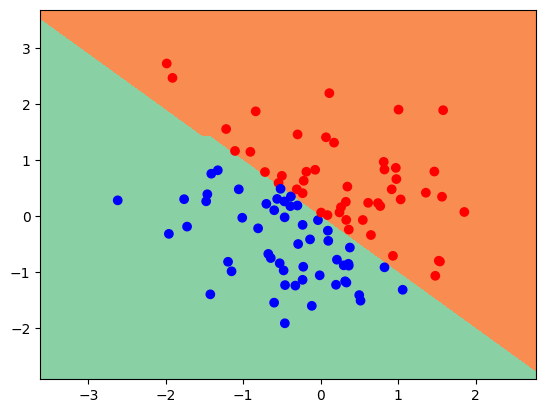

In [48]:
# Generate linearly separable data
n_features = 2
m = 100
X = np.random.randn(n_features, m)
Y = (X[0] + X[1] > 0).reshape(1, m).astype(int)

# Train a small network with ReLU hidden layers
parameters, ls = multi_layer_neural_network(X, Y, n_hs=[4, 3], num_epochs=2000, learning_rate=0.1,
                    hidden_activation='relu', print_cost=True)

# Evaluate
preds = predict(parameters, ls, X)
accuracy = np.mean(preds == Y) * 100
print(f"\nAccuracy: {accuracy:.1f}%")

# Visualize the learned boundary
plot_decision_boundary(predict, parameters, ls, X, Y)

## Testing on a non-linear problem

The whole point of multi-layer networks is to learn things linear models can't. Let's try the classic XOR-style problem: classify by whether the two features have the same sign.

A single perceptron (or logistic regression) cannot solve this. There's no straight line that separates the classes. But a multi-layer network with hidden units should handle it easily.


Accuracy: 100.0%


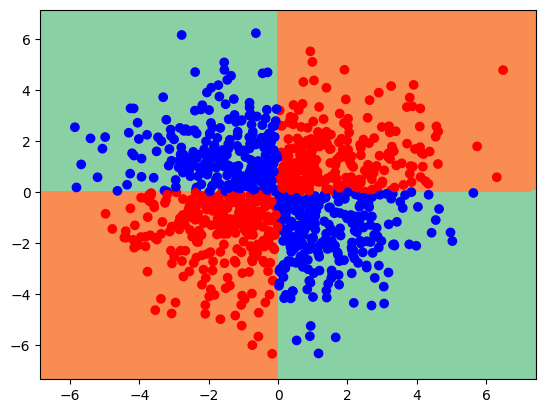

In [53]:
# Generate XOR-style data: positive class when features have same sign
n_features = 2
m = 1000
X = np.random.randn(n_features, m) * 2
Y = (X[0] * X[1] > 0).reshape(1, m).astype(int)

# Train a slightly bigger network
parameters, ls = multi_layer_neural_network(X, Y, n_hs=[8, 4], num_epochs=10000, learning_rate=0.1,
                    hidden_activation='relu')

# Evaluate
preds = predict(parameters, ls, X)
accuracy = np.mean(preds == Y) * 100
print(f"\nAccuracy: {accuracy:.1f}%")

plot_decision_boundary(predict, parameters, ls, X, Y)

## Concentric circles

Another classic non-linear problem: classify points based on whether they fall inside or outside a circle. The decision boundary should be circular, which is impossible for any linear model and trivial for a neural network.


Accuracy: 100.0%


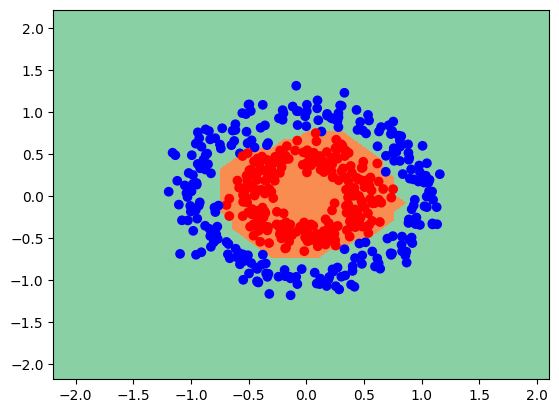

In [54]:
from sklearn.datasets import make_circles

# Generate two concentric rings of points
X_raw, Y_raw = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
X = X_raw.T                  # Reshape to (2, m)
Y = Y_raw.reshape(1, -1)     # Reshape to (1, m)

# Train
parameters, ls = multi_layer_neural_network(X, Y, n_hs=[16, 8], num_epochs=15000, learning_rate=0.1,
                    hidden_activation='relu')

# Evaluate
preds = predict(parameters, ls, X)
accuracy = np.mean(preds == Y) * 100
print(f"\nAccuracy: {accuracy:.1f}%")

plot_decision_boundary(predict, parameters, ls, X, Y)

## Comparing activation functions

Now that we have multiple activations available, let's compare them on the same problem. We'll train three networks with identical architectures but different hidden activations and see how they perform.

In [55]:
# Use the circles dataset for this comparison
X_raw, Y_raw = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
X = X_raw.T
Y = Y_raw.reshape(1, -1)

# Train one network per activation
results = {}
for activation in ['sigmoid', 'tanh', 'relu']:
    # Use a slightly lower learning rate for sigmoid since it can be unstable
    lr = 1.0 if activation == 'sigmoid' else 0.1

    parameters, ls = multi_layer_neural_network(X, Y, n_hs=[16, 8], num_epochs=10000,
                        learning_rate=lr, hidden_activation=activation)

    preds = predict(parameters, ls, X, hidden_activation=activation)
    acc = np.mean(preds == Y) * 100
    results[activation] = acc
    print(f"{activation}: {acc:.1f}% accuracy")

sigmoid: 99.8% accuracy
tanh: 99.8% accuracy
relu: 100.0% accuracy


## Summary

In this tutorial, we implemented a multi-layer neural network entirely from scratch:

1. **Architecture** described by a list of layer sizes
2. **Three activation functions** (sigmoid, tanh, ReLU) we can swap between
3. **Initialization** that scales based on the activation choice
4. **Forward propagation** to compute predictions
5. **Backward propagation** using the chain rule
6. **Gradient descent** to update parameters
7. **Training loop** combining all of the above
8. **Prediction and visualization** to interpret the results

The same fundamental ideas power every neural network, from this small implementation to GPT-scale models. The math doesn't change. Only the scale (more layers, more units, more data, different activation functions, and many engineering optimizations).

**Limitations of this implementation:**

- No mini-batching, we use full-batch gradient descent
- No regularization (L2, dropout, etc.) to prevent overfitting
- No advanced optimizers like Adam
- Only supports binary classification

**Next steps to explore:**

- Add L2 regularization or dropout for better generalization
- Implement mini-batch gradient descent for larger datasets
- Add support for multi-class classification with softmax
- Implement Adam or another adaptive optimizer
- Try training on MNIST or another real dataset

Once you understand the math here, frameworks like PyTorch and TensorFlow are mostly about scale and convenience. The core mechanics are exactly what we just built.